# Skin Lesion Classification: Monkeypox vs Non-Monkeypox
## Hybrid Handcrafted + Convolutional Feature Approach

**Course:** Pattern Recognition — Final Project  
**Team Members:** [Your Names Here]  
**Date:** June 2026

---

## Objective

Classify skin lesion images into **Monkeypox (MPX)** and **Non-Monkeypox (ETC)** using a hybrid
feature representation that combines:

1. **Handcrafted features** — Color moments, color histograms, GLCM texture, LBP,
   Gabor filters, Hu moments (shape), edge statistics, and FFT frequency features
2. **Convolutional features** — Embeddings from a pre-trained ResNet18
3. **Segmentation** — LAB color-space + Otsu thresholding with morphological cleanup

Classifiers evaluated: SVM (RBF), Random Forest, XGBoost, and Logistic Regression.


In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import fftpack

import cv2 as cv
from skimage import feature, filters, measure
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
from IPython.display import display
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 100})
np.random.seed(42)


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
MPX_PATH = "data/MPX"
ETC_PATH = "data/ETC"
METADATA_PATH = "data/metadata.csv"
FEATURES_DIR = "data/features"

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Image constant ──────────────────────────────────────────────────────────
IMG_SIZE = 224

os.makedirs(FEATURES_DIR, exist_ok=True)


Device: cuda


In [3]:
# Load metadata
metdat = pd.read_csv(METADATA_PATH)
print(f"Total entries in metadata: {len(metdat)}")
print(f"Label distribution:\n{metdat['Label'].value_counts()}")

# Build file paths
def get_image_path(row):
    folder = MPX_PATH if row["Label"] == "Monkeypox" else ETC_PATH
    return os.path.join(folder, f'{row["ImageID"]}.jpg')

metdat["path"] = metdat.apply(get_image_path, axis=1)
metdat["exists"] = metdat["path"].apply(os.path.exists)

missing = metdat[~metdat["exists"]]
if len(missing) > 0:
    print(f"\nMissing files ({len(missing)}):")
    for _, r in missing.iterrows():
        print(f"  {r['ImageID']} ({r['Label']})")

metdat = metdat[metdat["exists"]].reset_index(drop=True)
print(f"\nFinal dataset: {len(metdat)} images")
print(f"  Monkeypox  : {(metdat['Label'] == 'Monkeypox').sum()}")
print(f"  Non-Monkeypox: {(metdat['Label'] == 'Non Monkeypox').sum()}")

# Encode labels
le = LabelEncoder()
metdat["label_enc"] = le.fit_transform(metdat["Label"])
label_names = le.classes_
print(f"\nEncoded labels: 0={label_names[0]}, 1={label_names[1]}")


Total entries in metadata: 228
Label distribution:
Label
Non Monkeypox    126
Monkeypox        102
Name: count, dtype: int64

Final dataset: 228 images
  Monkeypox  : 102
  Non-Monkeypox: 126

Encoded labels: 0=Monkeypox, 1=Non Monkeypox


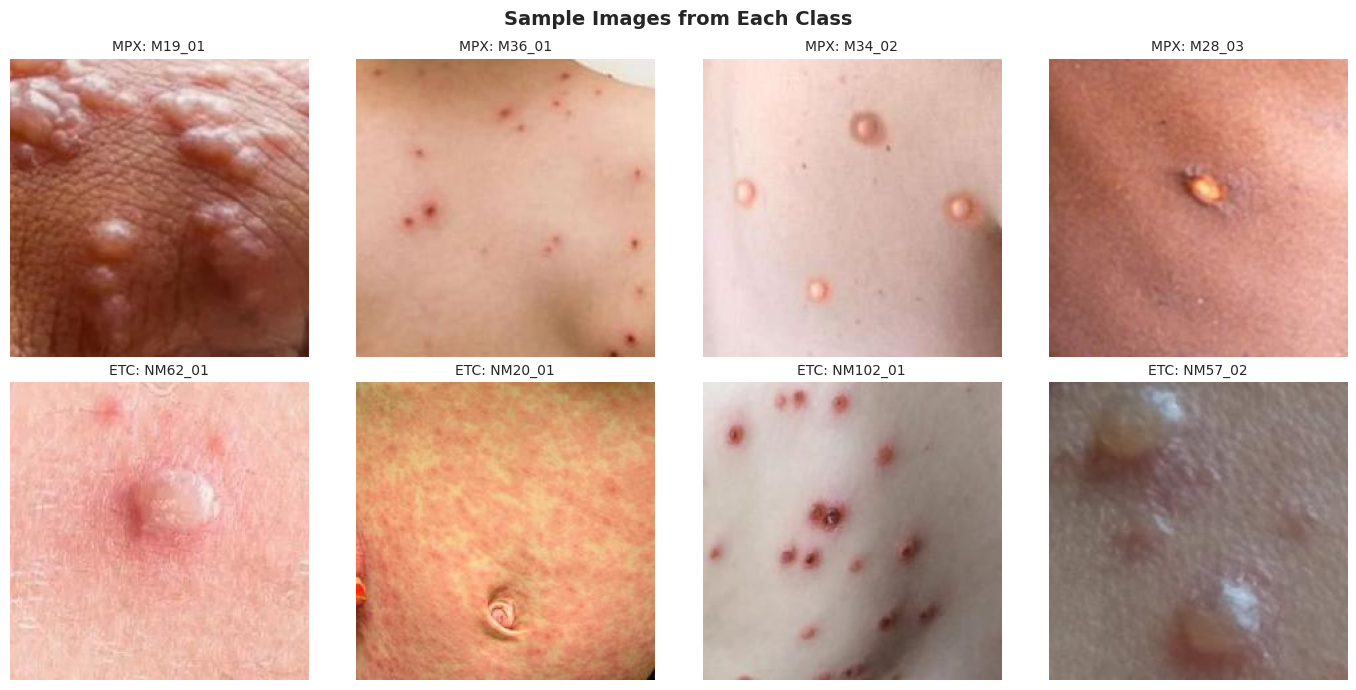

In [4]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

mpx_samples = metdat[metdat["Label"] == "Monkeypox"].sample(4, random_state=42)
etc_samples = metdat[metdat["Label"] == "Non Monkeypox"].sample(4, random_state=42)

for i, (_, row) in enumerate(mpx_samples.iterrows()):
    img = cv.cvtColor(cv.imread(row["path"]), cv.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"MPX: {row['ImageID']}", fontsize=10)
    axes[0, i].axis("off")

for i, (_, row) in enumerate(etc_samples.iterrows()):
    img = cv.cvtColor(cv.imread(row["path"]), cv.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"ETC: {row['ImageID']}", fontsize=10)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Monkeypox", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Non-Monkeypox", fontsize=12, fontweight="bold")
plt.suptitle("Sample Images from Each Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()


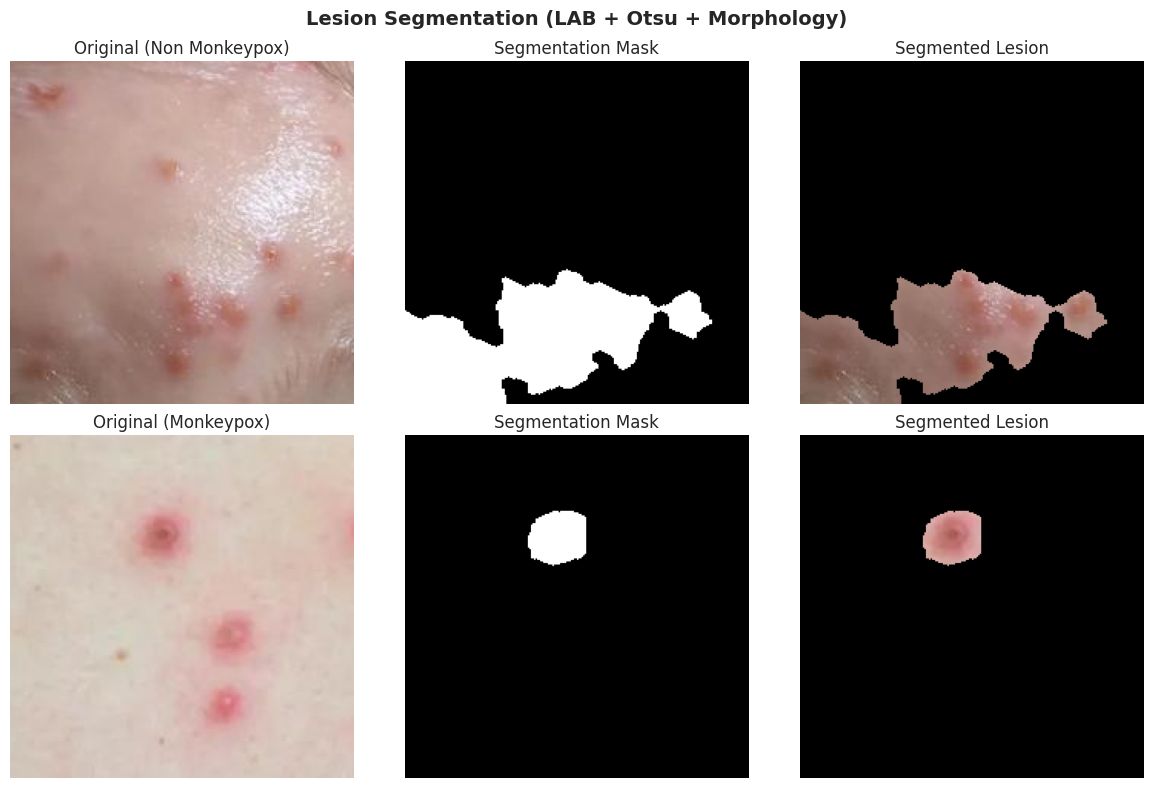

Segmentation demo complete.


In [5]:
def segment_lesion(img_bgr):
    """
    Segment skin lesion using LAB colour space + Otsu thresholding
    with morphological post-processing.
    
    Args:
        img_bgr: BGR image (uint8), shape (H, W, 3)
    
    Returns:
        mask: Binary mask (uint8, 0 or 255)
        segmented: Masked image (BGR, lesion region only)
    """
    lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

    # CLAHE contrast enhancement on L* channel
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(lab[:, :, 0])
    a_channel = clahe.apply(lab[:, :, 1])

    # Multi-channel Otsu approach: combine L* and a* responses
    l_f = l_channel.astype(np.float32)
    a_f = cv.bitwise_not(a_channel).astype(np.float32)
    combined = cv.addWeighted(l_f, 0.3, a_f, 0.7, 0).astype(np.uint8)

    _, mask = cv.threshold(combined, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # Invert if background is brighter (common for skin)
    if np.mean(mask) > 0.5 * 255:
        mask = 255 - mask

    # Morphological cleanup
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=2)
    mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)

    # Keep largest connected component
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(mask, 8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv.CC_STAT_AREA])
        mask = ((labels == largest).astype(np.uint8)) * 255

    segmented = cv.bitwise_and(img_bgr, img_bgr, mask=mask)
    return mask, segmented


# ── Visualise segmentation on samples ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, (_, row) in enumerate(metdat.sample(2, random_state=42).iterrows()):
    img_bgr = cv.imread(row["path"])
    mask, segmented = segment_lesion(img_bgr)

    axes[i, 0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original ({row['Label']})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Segmentation Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cv.cvtColor(segmented, cv.COLOR_BGR2RGB))
    axes[i, 2].set_title("Segmented Lesion")
    axes[i, 2].axis("off")

plt.suptitle("Lesion Segmentation (LAB + Otsu + Morphology)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("segmentation_example.png", dpi=150, bbox_inches="tight")
plt.show()
print("Segmentation demo complete.")


In [6]:
def _f(v):
    """Safely convert any numeric value to a Python float scalar."""
    try:
        return float(np.asarray(v).ravel()[0])
    except Exception:
        return 0.0


def extract_color_features(img_bgr, mask_bool, img_hsv, img_lab):
    """Colour moments + HSV histogram."""
    feats = {}

    for name, space in [("bgr", img_bgr), ("hsv", img_hsv), ("lab", img_lab)]:
        pixels = space[mask_bool]
        if len(pixels) < 10:
            pixels = space.reshape(-1, 3)
        for i, c in enumerate(["c1", "c2", "c3"]):
            ch = pixels[:, i].astype(np.float64)
            feats[f"{name}_{c}_mean"] = _f(np.mean(ch))
            feats[f"{name}_{c}_std"]  = _f(np.std(ch))
            sk = ch.std() / (ch.mean() + 1e-7) if ch.std() > 1e-10 else 0.0
            feats[f"{name}_{c}_cv"]  = _f(sk)  # coefficient of variation (robust)

    hsv_px = img_hsv[mask_bool]
    for i, c in enumerate(["h", "s", "v"]):
        hist, _ = np.histogram(hsv_px[:, i], bins=16, range=(0, 256))
        hist = hist.astype(np.float64) / (hist.sum() + 1e-7)
        for j in range(16):
            feats[f"hsv_hist_{c}_{j:02d}"] = _f(hist[j])
        # add colour channel percentiles
        feats[f"hsv_{c}_p05"] = _f(np.percentile(hsv_px[:, i], 5))
        feats[f"hsv_{c}_p50"] = _f(np.percentile(hsv_px[:, i], 50))
        feats[f"hsv_{c}_p95"] = _f(np.percentile(hsv_px[:, i], 95))

    return feats


def extract_texture_features(img_bgr, gray, mask_bool):
    """GLCM + LBP + Gabor."""
    feats = {}

    # GLCM — 4 angles, distances=1; use 64 levels for speed & robustness
    gray64 = ((gray.astype(np.float64) / 256.0) * 63).astype(np.uint8)
    glcm = graycomatrix(gray64, distances=[1, 2],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop).flatten()
        feats[f"glcm_{prop}_mean"] = _f(np.mean(vals))
        feats[f"glcm_{prop}_std"]  = _f(np.std(vals))

    # LBP — uniform, radius=2, P=16  (fewer bins, faster)
    radius, n_pts = 2, 16
    lbp = local_binary_pattern(gray, n_pts, radius, method="uniform")
    n_bins = n_pts + 2
    lbp_vals = lbp[mask_bool]
    if len(lbp_vals) > 0:
        lbp_hist, _ = np.histogram(lbp_vals, bins=np.arange(0, n_bins + 1), density=True)
    else:
        lbp_hist = np.zeros(n_bins)
    for j in range(n_bins):
        feats[f"lbp_bin_{j:02d}"] = _f(lbp_hist[j])

    # Gabor — 3 orientations, 2 scales (fewer = faster, ~6 filters)
    thetas = np.arange(0, np.pi, np.pi / 3)
    sigmas = [1.5, 3.0]
    for k, theta in enumerate(thetas):
        for s, sigma in enumerate(sigmas):
            freq = 1.0 / sigma
            try:
                real, imag = filters.gabor(gray, frequency=freq, theta=theta)
                mag = np.sqrt(real ** 2 + imag ** 2)
                vals = mag[mask_bool]
                feats[f"gabor_mean_t{k}_s{s}"] = _f(np.mean(vals))
                feats[f"gabor_std_t{k}_s{s}"]  = _f(np.std(vals))
            except Exception:
                feats[f"gabor_mean_t{k}_s{s}"] = 0.0
                feats[f"gabor_std_t{k}_s{s}"]  = 0.0

    return feats


def extract_shape_features(mask):
    """Hu moments + region properties."""
    feats = {}

    m = cv.moments(mask)
    hu = cv.HuMoments(m)
    for i in range(7):
        feats[f"hu_moment_{i}"] = _f(-np.sign(hu[i, 0]) * np.log10(np.abs(hu[i, 0]) + 1e-10))

    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv.contourArea)
        area = cv.contourArea(cnt)
        perimeter = cv.arcLength(cnt, True)
        hull = cv.convexHull(cnt)
        hull_area = cv.contourArea(hull)
        x, y, w, h = cv.boundingRect(cnt)

        if perimeter > 0:
            feats["circularity"] = _f(4 * np.pi * area / (perimeter ** 2))
        if area > 0:
            feats["aspect_ratio"] = _f(w / h if h > 0 else 0)
            feats["extent"] = _f(area / (w * h) if w * h > 0 else 0)
        if hull_area > 0:
            feats["solidity"] = _f(area / hull_area)

        # eccentricity via regionprops
        props = measure.regionprops(mask.astype(int))
        if props:
            feats["eccentricity"] = _f(props[0].eccentricity)
            feats["major_axis"]   = _f(props[0].major_axis_length)
            feats["minor_axis"]   = _f(props[0].minor_axis_length)

    return feats


def extract_edge_features(gray, mask_bool):
    """Canny density + Sobel gradient stats."""
    feats = {}
    edges = cv.Canny(gray, 50, 150)
    feats["edge_density"] = _f(np.sum(edges > 0) / edges.size)

    sobel_x = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
    sobel_y = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
    grad = mag[mask_bool] if mask_bool is not None else mag.flatten()
    feats["gradient_mean"] = _f(np.mean(grad))
    feats["gradient_std"]  = _f(np.std(grad))
    return feats


def extract_fft_features(gray):
    """Radial power spectrum."""
    feats = {}
    f = fftpack.fft2(gray.astype(float))
    fshift = fftpack.fftshift(f)
    mag = np.abs(fshift)
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    max_r = min(cy, cx)
    step = max(1, max_r // 8)
    i = 0
    for r in range(step, max_r, step):
        y, x = np.ogrid[-cy : h - cy, -cx : w - cx]
        ring = (r <= np.sqrt(x**2 + y**2)) & (np.sqrt(x**2 + y**2) < r + step)
        vals = mag[ring]
        if len(vals) > 0:
            feats[f"fft_ring_{i}_mean"] = _f(np.mean(vals))
            feats[f"fft_ring_{i}_std"]  = _f(np.std(vals))
            i += 1
    return feats


def extract_handcrafted_features(img_bgr):
    """Master function — extract all handcrafted features from one image."""
    mask, _ = segment_lesion(img_bgr)
    mask_bool = mask.astype(bool)

    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    hsv  = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    lab  = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

    feats = {}
    feats.update(extract_color_features(img_bgr, mask_bool, hsv, lab))
    feats.update(extract_texture_features(img_bgr, gray, mask_bool))
    feats.update(extract_shape_features(mask))
    feats.update(extract_edge_features(gray, mask_bool))
    feats.update(extract_fft_features(gray))

    return feats


print("Handcrafted feature extraction functions defined.")
print(f"Feature categories: Colour, GLCM, LBP, Gabor, Hu-moments, Edges, FFT")


Handcrafted feature extraction functions defined.
Feature categories: Colour, GLCM, LBP, Gabor, Hu-moments, Edges, FFT


In [7]:
# ── Load pre-trained ResNet18 (feature extractor) ────────────────────────
cnn_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
cnn_model = torch.nn.Sequential(*list(cnn_model.children())[:-1])  # drop FC layer
cnn_model = cnn_model.to(DEVICE)
cnn_model.eval()

# ── Preprocessing pipeline ─────────────────────────────────────────────────
cnn_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_cnn_features(img_path):
    """Extract ResNet18 embedding (512-d) from a single image."""
    img = Image.open(img_path).convert("RGB")
    tensor = cnn_transform(img).unsqueeze(0).to(DEVICE)
    vec = cnn_model(tensor)
    return vec.squeeze().cpu().numpy().flatten()

print(f"CNN feature extractor: ResNet18 → 512-d embedding")
print(f"Preprocessing: {IMG_SIZE}×{IMG_SIZE}, ImageNet normalisation")


CNN feature extractor: ResNet18 → 512-d embedding
Preprocessing: 224×224, ImageNet normalisation


In [8]:
# ── Check for cached features ─────────────────────────────────────────────
pkl_path = os.path.join(FEATURES_DIR, "all_features.pkl")

if os.path.exists(pkl_path):
    print("Loading cached features...")
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_hand = data["X_hand"]
    X_cnn = data["X_cnn"]
    y = data["y"]
    feat_names = data["feat_names"]
    print(f"Loaded from cache: {X_hand.shape[1]} handcrafted + {X_cnn.shape[1]} CNN features")

else:
    print("Extracting features — this may take several minutes...\n")

    # Extract handcrafted features
    all_hand = []
    for _, row in tqdm(metdat.iterrows(), total=len(metdat), desc="Handcrafted"):
        img_bgr = cv.imread(row["path"])
        feats = extract_handcrafted_features(img_bgr)
        all_hand.append(feats)

    df_hand = pd.DataFrame(all_hand)
    df_hand = df_hand.fillna(0).replace([np.inf, -np.inf], 0)
    feat_names = df_hand.columns.tolist()
    X_hand = df_hand.values.astype(np.float64)

    print(f"Handcrafted features: {X_hand.shape[1]}")

    # Extract CNN features
    X_cnn_list = []
    for _, row in tqdm(metdat.iterrows(), total=len(metdat), desc="CNN (ResNet18)"):
        vec = extract_cnn_features(row["path"])
        X_cnn_list.append(vec)

    X_cnn = np.array(X_cnn_list, dtype=np.float64)
    print(f"CNN features: {X_cnn.shape[1]}")

    y = metdat["label_enc"].values

    # Cache
    os.makedirs(FEATURES_DIR, exist_ok=True)
    with open(pkl_path, "wb") as f:
        pickle.dump({"X_hand": X_hand, "X_cnn": X_cnn, "y": y, "feat_names": feat_names}, f)
    print(f"\nFeatures cached to {pkl_path}")

print(f"\nSamples: {len(y)}  |  MPX: {(y == 0).sum()}  |  ETC: {(y == 1).sum()}")


Loading cached features...
Loaded from cache: 155 handcrafted + 512 CNN features

Samples: 228  |  MPX: 102  |  ETC: 126


In [9]:
# Stratified split: 70 % train, 30 % test
indices = np.arange(len(y))
idx_train, idx_test = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {len(idx_train)}  ({len(idx_train)/len(y)*100:.1f}%)")
print(f"Test : {len(idx_test)}  ({len(idx_test)/len(y)*100:.1f}%)")
print(f"Train class balance: {np.bincount(y[idx_train])}")
print(f"Test  class balance: {np.bincount(y[idx_test])}")


Train: 159  (69.7%)
Test : 69  (30.3%)
Train class balance: [71 88]
Test  class balance: [31 38]


In [10]:
# ── Remove near-zero-variance features ────────────────────────────────────
var_filter = VarianceThreshold(threshold=1e-6)
X_hand_clean = var_filter.fit_transform(X_hand)
kept_mask = var_filter.get_support()
feat_names_clean = [n for n, k in zip(feat_names, kept_mask) if k]
print(f"Handcrafted after variance filter: {X_hand_clean.shape[1]} (removed {X_hand.shape[1] - X_hand_clean.shape[1]})")

# ── Scale ──────────────────────────────────────────────────────────────────
scaler_hand = StandardScaler()
scaler_cnn = StandardScaler()

X_hand_scaled = scaler_hand.fit_transform(X_hand_clean)
X_cnn_scaled = scaler_cnn.fit_transform(X_cnn)

# ── Build feature-sets ─────────────────────────────────────────────────────
# Handcrafted only
X_h_train, X_h_test = X_hand_scaled[idx_train], X_hand_scaled[idx_test]
# CNN only
X_c_train, X_c_test = X_cnn_scaled[idx_train], X_cnn_scaled[idx_test]
# Hybrid (concatenated)
X_hy_train = np.hstack([X_hand_scaled[idx_train], X_cnn_scaled[idx_train]])
X_hy_test  = np.hstack([X_hand_scaled[idx_test],  X_cnn_scaled[idx_test]])

y_train, y_test = y[idx_train], y[idx_test]

print(f"\nHandcrafted-dim: {X_h_train.shape[1]}")
print(f"CNN-dim       : {X_c_train.shape[1]}")
print(f"Hybrid-dim    : {X_hy_train.shape[1]}")


Handcrafted after variance filter: 151 (removed 4)

Handcrafted-dim: 151
CNN-dim       : 512
Hybrid-dim    : 663


In [11]:
# Select top-k hybrid features via mutual information
k_select = min(200, X_hy_train.shape[1])
selector = SelectKBest(mutual_info_classif, k=k_select)
selector.fit(X_hy_train, y_train)

X_hy_train_sel = selector.transform(X_hy_train)
X_hy_test_sel  = selector.transform(X_hy_test)

print(f"Hybrid after MI selection: {X_hy_train_sel.shape[1]} features (top {k_select})")

# ── Define evaluation dict ─────────────────────────────────────────────────
datasets = {
    "Handcrafted":         (X_h_train, X_h_test),
    "CNN (ResNet18)":      (X_c_train, X_c_test),
    "Hybrid (selected)":   (X_hy_train_sel, X_hy_test_sel),
    "Hybrid (full)":       (X_hy_train, X_hy_test),
}


Hybrid after MI selection: 200 features (top 200)


In [12]:
classifiers = {
    "SVM (RBF)":          SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42),
    "Random Forest":      RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost":            XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         random_state=42, verbosity=0),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=5000, random_state=42),
}

results = []
all_y_probs = {}  # for ROC curves

for ds_name, (X_tr, X_te) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  Feature-set: {ds_name}  ({X_tr.shape[1]} dims)")
    print(f"{'='*60}")

    for clf_name, clf in classifiers.items():
        # 5-fold CV on training set
        cv_scores = cross_validate(
            clf, X_tr, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42),
            scoring=["accuracy", "f1_macro", "roc_auc"],
            return_train_score=False,
        )
        cv_acc  = cv_scores["test_accuracy"].mean()
        cv_f1   = cv_scores["test_f1_macro"].mean()
        cv_auc  = cv_scores["test_roc_auc"].mean()

        # Fit on full training set, evaluate on test
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]

        test_acc = accuracy_score(y_test, y_pred)
        test_f1  = f1_score(y_test, y_pred, average="macro")
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        test_auc = auc(fpr, tpr)

        results.append({
            "Feature Set": ds_name,
            "Classifier": clf_name,
            "CV Accuracy": cv_acc,
            "CV F1 (macro)": cv_f1,
            "CV AUC": cv_auc,
            "Test Accuracy": test_acc,
            "Test F1 (macro)": test_f1,
            "Test AUC": test_auc,
        })

        all_y_probs[f"{ds_name}|{clf_name}"] = (y_test, y_prob)

        print(f"  {clf_name:25s}  CV-Acc={cv_acc:.3f}  CV-F1={cv_f1:.3f}  "
              f"CV-AUC={cv_auc:.3f}  |  Test-Acc={test_acc:.3f}  Test-F1={test_f1:.3f}  Test-AUC={test_auc:.3f}")

# ── Results table ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).round(4)
print(f"\n{'='*80}")
print("RESULTS SUMMARY (sorted by Test AUC)")
print(f"{'='*80}")
display(df_results.sort_values("Test AUC", ascending=False))



  Feature-set: Handcrafted  (151 dims)
  SVM (RBF)                  CV-Acc=0.718  CV-F1=0.714  CV-AUC=0.776  |  Test-Acc=0.594  Test-F1=0.592  Test-AUC=0.711


  Random Forest              CV-Acc=0.749  CV-F1=0.739  CV-AUC=0.794  |  Test-Acc=0.739  Test-F1=0.735  Test-AUC=0.784


  XGBoost                    CV-Acc=0.680  CV-F1=0.673  CV-AUC=0.768  |  Test-Acc=0.754  Test-F1=0.752  Test-AUC=0.840
  Logistic Regression        CV-Acc=0.724  CV-F1=0.714  CV-AUC=0.763  |  Test-Acc=0.667  Test-F1=0.666  Test-AUC=0.778

  Feature-set: CNN (ResNet18)  (512 dims)
  SVM (RBF)                  CV-Acc=0.786  CV-F1=0.784  CV-AUC=0.891  |  Test-Acc=0.855  Test-F1=0.853  Test-AUC=0.949


  Random Forest              CV-Acc=0.736  CV-F1=0.728  CV-AUC=0.821  |  Test-Acc=0.812  Test-F1=0.806  Test-AUC=0.911


  XGBoost                    CV-Acc=0.693  CV-F1=0.686  CV-AUC=0.805  |  Test-Acc=0.797  Test-F1=0.794  Test-AUC=0.869
  Logistic Regression        CV-Acc=0.743  CV-F1=0.736  CV-AUC=0.847  |  Test-Acc=0.826  Test-F1=0.823  Test-AUC=0.887

  Feature-set: Hybrid (selected)  (200 dims)
  SVM (RBF)                  CV-Acc=0.805  CV-F1=0.802  CV-AUC=0.916  |  Test-Acc=0.841  Test-F1=0.840  Test-AUC=0.923


  Random Forest              CV-Acc=0.768  CV-F1=0.760  CV-AUC=0.845  |  Test-Acc=0.812  Test-F1=0.806  Test-AUC=0.878


  XGBoost                    CV-Acc=0.743  CV-F1=0.739  CV-AUC=0.833  |  Test-Acc=0.855  Test-F1=0.848  Test-AUC=0.907
  Logistic Regression        CV-Acc=0.761  CV-F1=0.756  CV-AUC=0.858  |  Test-Acc=0.812  Test-F1=0.810  Test-AUC=0.867

  Feature-set: Hybrid (full)  (663 dims)
  SVM (RBF)                  CV-Acc=0.805  CV-F1=0.803  CV-AUC=0.915  |  Test-Acc=0.826  Test-F1=0.825  Test-AUC=0.928


  Random Forest              CV-Acc=0.761  CV-F1=0.753  CV-AUC=0.822  |  Test-Acc=0.812  Test-F1=0.808  Test-AUC=0.902


  XGBoost                    CV-Acc=0.699  CV-F1=0.691  CV-AUC=0.798  |  Test-Acc=0.841  Test-F1=0.838  Test-AUC=0.890
  Logistic Regression        CV-Acc=0.793  CV-F1=0.789  CV-AUC=0.896  |  Test-Acc=0.812  Test-F1=0.808  Test-AUC=0.885

RESULTS SUMMARY (sorted by Test AUC)


,Feature Set,Classifier,CV Accuracy,CV F1 (macro),CV AUC,Test Accuracy,Test F1 (macro),Test AUC
4,CNN (ResNet18),SVM (RBF),0.7863,0.7841,0.8910,0.8551,0.8526,0.9491
12,Hybrid (full),SVM (RBF),0.8052,0.8033,0.9148,0.8261,0.8252,0.9278
8,Hybrid (selected),SVM (RBF),0.8052,0.8016,0.9157,0.8406,0.8400,0.9228
5,CNN (ResNet18),Random Forest,0.7359,0.7277,0.8211,0.8116,0.8057,0.9113
10,Hybrid (selected),XGBoost,0.7427,0.7388,0.8333,0.8551,0.8479,0.9075
13,Hybrid (full),Random Forest,0.7613,0.7525,0.8219,0.8116,0.8076,0.9024
14,Hybrid (full),XGBoost,0.6988,0.6913,0.7978,0.8406,0.8384,0.8896
7,CNN (ResNet18),Logistic Regression,0.7425,0.7356,0.8472,0.8261,0.8231,0.8871
15,Hybrid (full),Logistic Regression,0.7925,0.7888,0.8964,0.8116,0.8076,0.8854
9,Hybrid (selected),Random Forest,0.7679,0.7605,0.8449,0.8116,0.8057,0.8782


In [13]:
# ── Identify best model ────────────────────────────────────────────────────
best_row = df_results.loc[df_results["Test AUC"].idxmax()]
best_ds = best_row["Feature Set"]
best_clf_name = best_row["Classifier"]
print(f"Best model: {best_clf_name} + {best_ds}")
print(f"Test AUC: {best_row['Test AUC']:.4f}  |  Test Acc: {best_row['Test Accuracy']:.4f}")

# ── Retrain best with full detail ──────────────────────────────────────────
X_tr_best, X_te_best = datasets[best_ds]
best_clf = classifiers[best_clf_name]
best_clf.fit(X_tr_best, y_train)
y_pred_best = best_clf.predict(X_te_best)
y_prob_best = best_clf.predict_proba(X_te_best)[:, 1]

print(f"\nClassification Report ({best_clf_name} + {best_ds}):")
print(classification_report(y_test, y_pred_best, target_names=label_names))


Best model: SVM (RBF) + CNN (ResNet18)
Test AUC: 0.9491  |  Test Acc: 0.8551

Classification Report (SVM (RBF) + CNN (ResNet18)):
               precision    recall  f1-score   support

    Monkeypox       0.86      0.81      0.83        31
Non Monkeypox       0.85      0.89      0.87        38

     accuracy                           0.86        69
    macro avg       0.86      0.85      0.85        69
 weighted avg       0.86      0.86      0.85        69



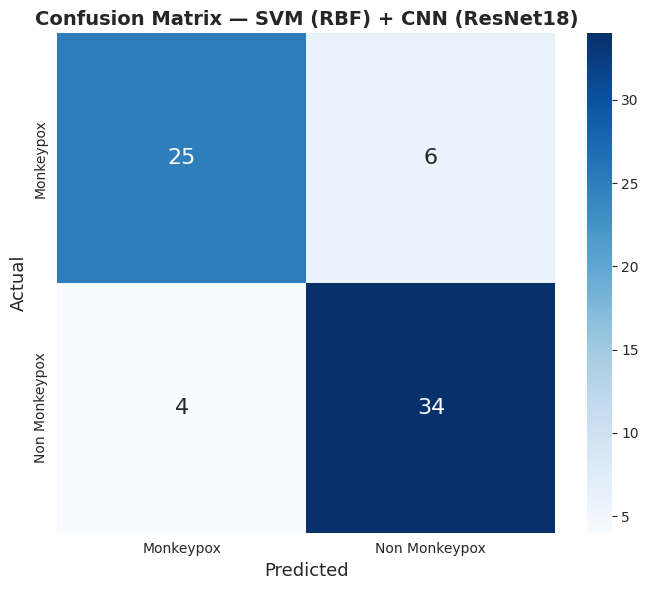

In [14]:
# ── Confusion matrix for best model ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"fontsize": 16})
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title(f"Confusion Matrix — {best_clf_name} + {best_ds}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


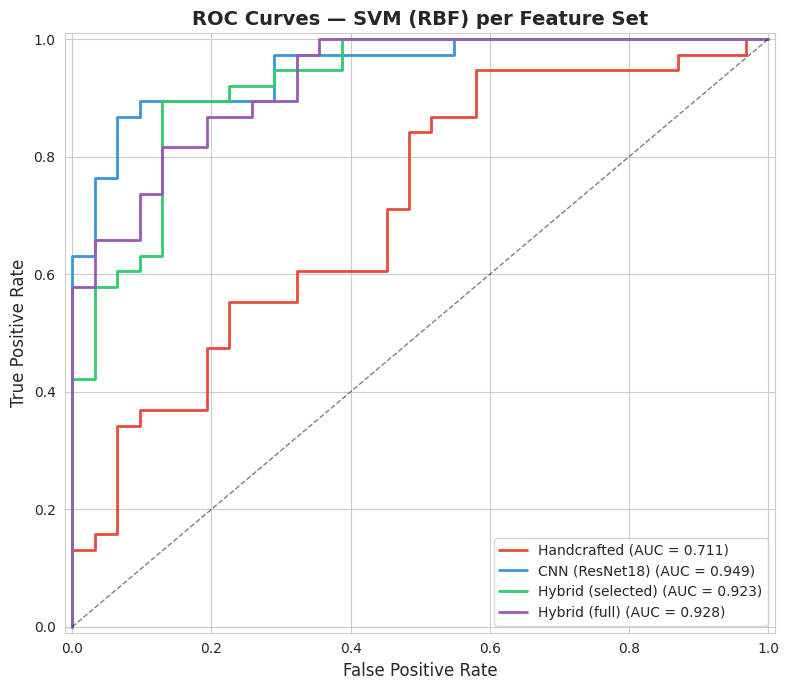

In [15]:
# ── ROC curves for all feature-sets with best classifier (SVM) ───────────
fig, ax = plt.subplots(figsize=(8, 7))
colors = {"Handcrafted": "#e74c3c", "CNN (ResNet18)": "#3498db",
          "Hybrid (selected)": "#2ecc71", "Hybrid (full)": "#9b59b6"}

for ds_name in datasets.keys():
    key = f"{ds_name}|SVM (RBF)"
    if key in all_y_probs:
        yt, yp = all_y_probs[key]
        fpr, tpr, _ = roc_curve(yt, yp)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors.get(ds_name, "#333"), lw=2,
                label=f"{ds_name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — SVM (RBF) per Feature Set", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


Running t-SNE on hybrid features (selected)...


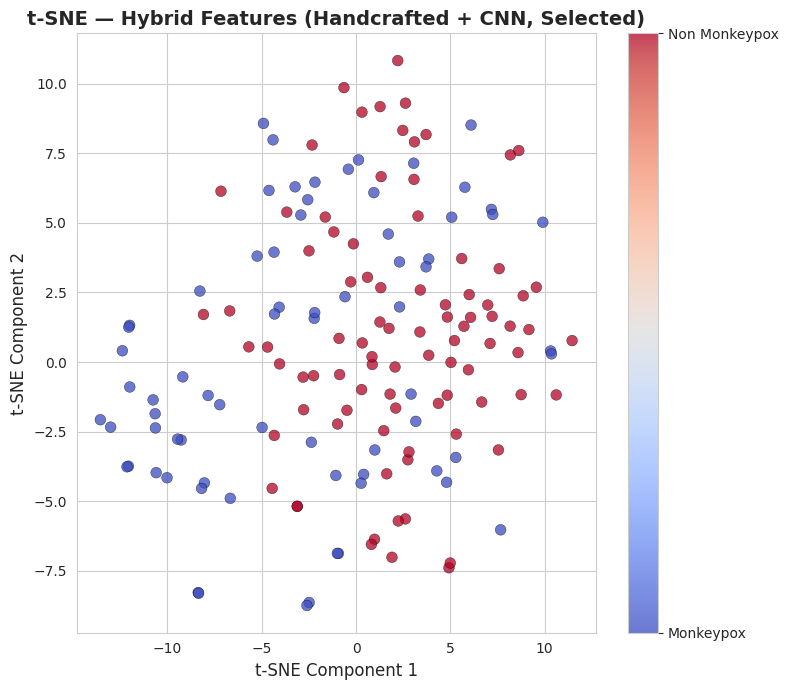

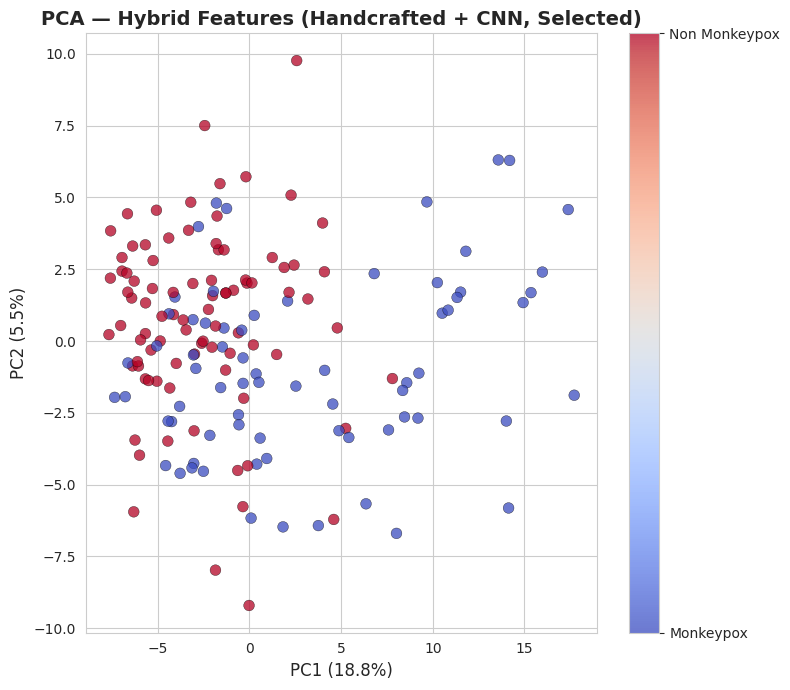

PCA explained variance: PC1=18.79%, PC2=5.55%


In [16]:
# ── t-SNE on hybrid features ──────────────────────────────────────────────
print("Running t-SNE on hybrid features (selected)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(y_train)-1), max_iter=1000)
X_tsne = tsne.fit_transform(X_hy_train_sel)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap="coolwarm",
                     alpha=0.75, edgecolors="k", linewidth=0.3, s=60)
ax.set_xlabel("t-SNE Component 1", fontsize=12)
ax.set_ylabel("t-SNE Component 2", fontsize=12)
ax.set_title("t-SNE — Hybrid Features (Handcrafted + CNN, Selected)", fontsize=14, fontweight="bold")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(label_names)
plt.tight_layout()
plt.savefig("tsne_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PCA for comparison ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_hy_train_sel)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="coolwarm",
                     alpha=0.75, edgecolors="k", linewidth=0.3, s=60)
ax.set_xlabel(f"PC1 ({explained[0]:.1%})", fontsize=12)
ax.set_ylabel(f"PC2 ({explained[1]:.1%})", fontsize=12)
ax.set_title("PCA — Hybrid Features (Handcrafted + CNN, Selected)", fontsize=14, fontweight="bold")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(label_names)
plt.tight_layout()
plt.savefig("pca_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}")


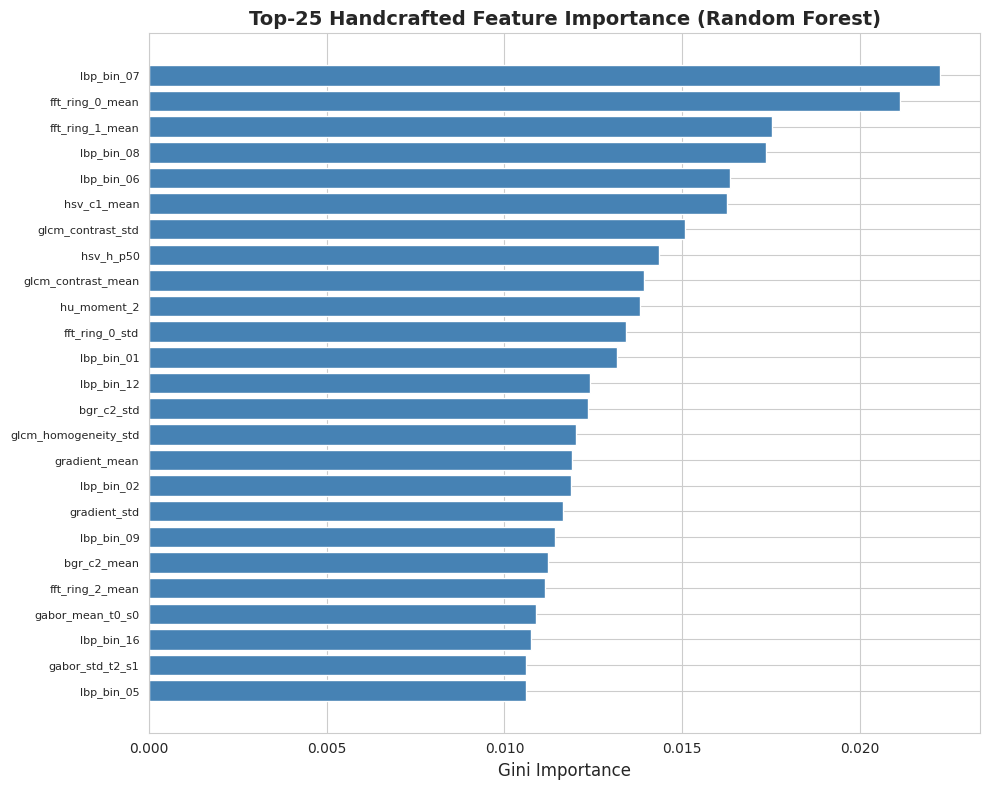

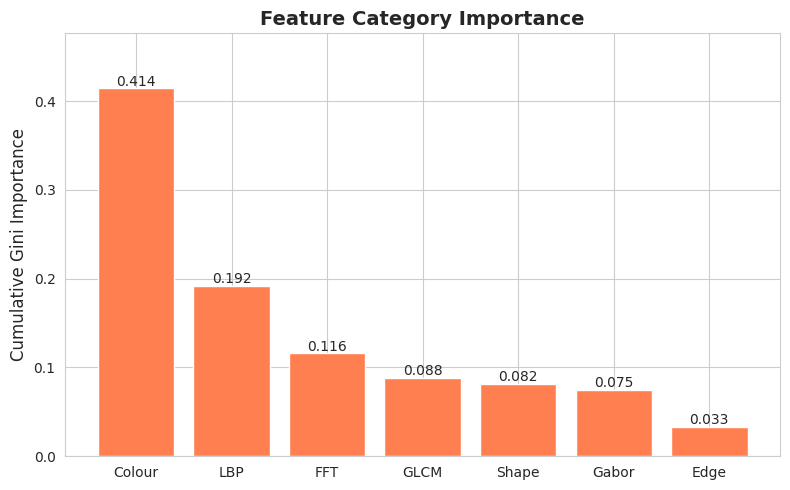

In [17]:
# ── Train RF on handcrafted-only to see importance ────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_h_train, y_train)

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-25:][::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_idx)), importances[top_idx], color="steelblue")
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([feat_names_clean[i] for i in top_idx], fontsize=8)
ax.set_xlabel("Gini Importance", fontsize=12)
ax.set_title("Top-25 Handcrafted Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-category summary ───────────────────────────────────────────────────
categories = {
    "Colour": [n for n in feat_names_clean if any(p in n for p in ("bgr_", "hsv_", "lab_"))],
    "GLCM":   [n for n in feat_names_clean if n.startswith("glcm_")],
    "LBP":    [n for n in feat_names_clean if n.startswith("lbp_")],
    "Gabor":  [n for n in feat_names_clean if n.startswith("gabor_")],
    "Shape":  [n for n in feat_names_clean if any(p in n for p in ("hu_", "circularity", "aspect", "extent", "solidity", "eccentricity", "axis"))],
    "Edge":   [n for n in feat_names_clean if n.startswith("edge_") or n.startswith("gradient_")],
    "FFT":    [n for n in feat_names_clean if n.startswith("fft_")],
}

cat_importance = {}
for cat, names in categories.items():
    indices = [feat_names_clean.index(n) for n in names if n in feat_names_clean]
    if indices:
        cat_importance[cat] = importances[indices].sum()

fig, ax = plt.subplots(figsize=(8, 5))
cats_sorted = sorted(cat_importance.items(), key=lambda x: x[1], reverse=True)
ax.bar([c[0] for c in cats_sorted], [c[1] for c in cats_sorted], color="coral")
ax.set_ylabel("Cumulative Gini Importance", fontsize=12)
ax.set_title("Feature Category Importance", fontsize=14, fontweight="bold")
for i, (cat, imp) in enumerate(cats_sorted):
    ax.text(i, imp + 0.003, f"{imp:.3f}", ha="center", fontsize=10)
ax.set_ylim(0, max(c[1] for c in cats_sorted) * 1.15)
plt.tight_layout()
plt.savefig("category_importance.png", dpi=150, bbox_inches="tight")
plt.show()


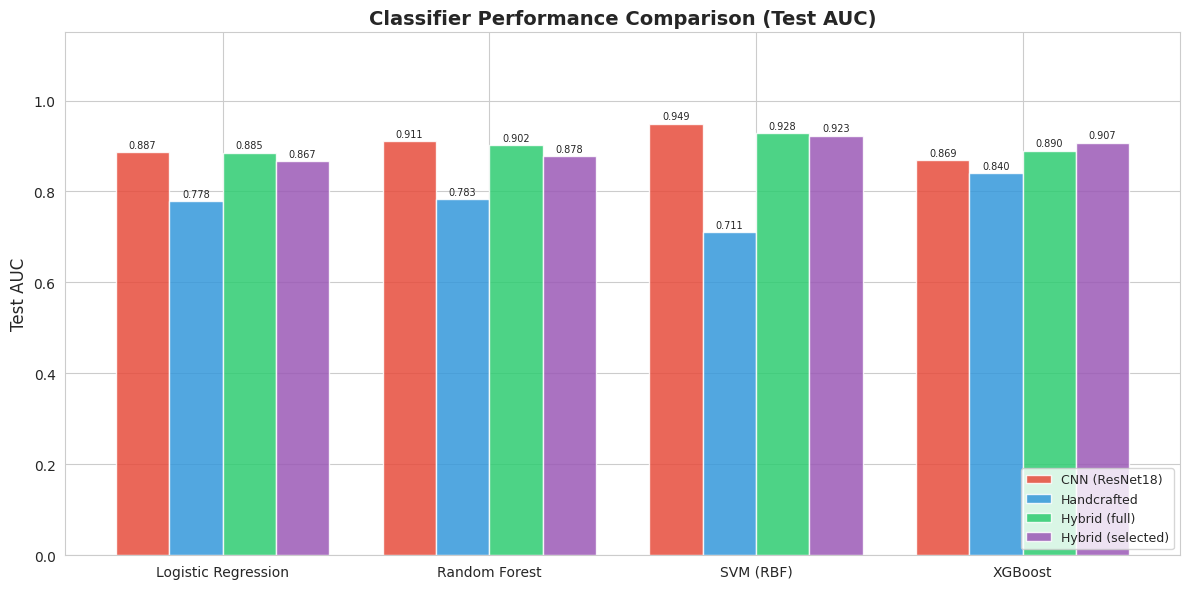

In [18]:
# ── Bar chart comparing CV AUC across feature-sets and classifiers ───────
pivot = df_results.pivot_table(
    index="Classifier", columns="Feature Set", values="Test AUC"
)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pivot))
width = 0.2
n_sets = len(pivot.columns)
colours = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]

for i, col in enumerate(pivot.columns):
    offset = (i - n_sets / 2 + 0.5) * width
    bars = ax.bar(x + offset, pivot[col], width, label=col, color=colours[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=10)
ax.set_ylabel("Test AUC", fontsize=12)
ax.set_title("Classifier Performance Comparison (Test AUC)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig("classifier_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# ── Save best model, scalers for reuse ─────────────────────────────────────
best_model_dir = "model"
os.makedirs(best_model_dir, exist_ok=True)

with open(os.path.join(best_model_dir, "best_clf.pkl"), "wb") as f:
    pickle.dump(best_clf, f)
with open(os.path.join(best_model_dir, "scaler_hand.pkl"), "wb") as f:
    pickle.dump(scaler_hand, f)
with open(os.path.join(best_model_dir, "scaler_cnn.pkl"), "wb") as f:
    pickle.dump(scaler_cnn, f)
with open(os.path.join(best_model_dir, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)
with open(os.path.join(best_model_dir, "feat_names.pkl"), "wb") as f:
    pickle.dump(feat_names_clean, f)

print(f"Best classifier and preprocessing objects saved to '{best_model_dir}/'")
print("Done — notebook execution complete.")


Best classifier and preprocessing objects saved to 'model/'
Done — notebook execution complete.
